In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import re
import time

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)  # Chia tập dữ liệu và K-Fold phân tầng
from scipy.stats import skew, f_oneway, kruskal

from scipy.stats import pearsonr

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.mixture import (
    GaussianMixture,
)  # Import mô hình Gaussian Mixture Model
from sklearn.metrics import (
    mean_absolute_percentage_error,
    r2_score,mean_absolute_percentage_error,
        mean_squared_error,
        mean_absolute_error,
)  # Metric đánh giá sai số MAPE

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)  # Chia tập dữ liệu và K-Fold phân tầng
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [37]:
df_0 = pd.read_parquet("G:\\My Drive\\Data\\Data - Sagonap\\BDS.parquet")
df_0_eda = df_0.copy()

In [38]:
df_0.describe(include='all')

,id,propertyId,appraisalContractId,certificateNo,statusName,certificateDate,fullAddress,priceEstimatedByStaff,location,landType,houseType,areaTotal,areaTotalWidth,areaTotalLength,areaTotalBackWidth,areaLegal,areaResidential
count,2717.000000,2717.000000,2717.000000,2717,2717,2717,2717,2.713000e+03,2707,2717,2717,2712.000000,2711.000000,2711.000000,2669.000000,2712.000000,913.000000
unique,NaN,NaN,NaN,2150,4,1429,2659,NaN,2,10,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,019/2025/1405886/CMU,Đóng,2024-08-13T00:00:00+07:00,"Thửa đất số 583, Tờ bản đồ số 8, Phường Long T...",NaN,h-front,land-residential,tp-none,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,9,1685,16,2,NaN,2306,1098,2220,NaN,NaN,NaN,NaN,NaN,NaN
mean,212497.681634,842530.434303,214422.006625,NaN,NaN,NaN,NaN,3.312607e+09,NaN,NaN,NaN,3018.764978,20.832328,75.425769,22.575826,2963.269056,265.032147
std,26107.179490,36743.350491,25126.906190,NaN,NaN,NaN,NaN,5.336340e+09,NaN,NaN,NaN,12839.151008,34.991569,110.980585,40.168574,12830.549785,273.545645
min,170084.000000,705705.000000,174103.000000,NaN,NaN,NaN,NaN,6.092100e+07,NaN,NaN,NaN,1.000000,0.880000,1.000000,0.000000,1.000000,9.700000
25%,191177.000000,813317.000000,193720.000000,NaN,NaN,NaN,NaN,1.094466e+09,NaN,NaN,NaN,124.200000,5.000000,20.890000,5.000000,119.500000,100.000000
50%,210322.000000,839570.000000,212211.000000,NaN,NaN,NaN,NaN,2.049405e+09,NaN,NaN,NaN,351.000000,9.500000,37.550000,10.000000,328.700000,200.000000
75%,232419.000000,870235.000000,233488.000000,NaN,NaN,NaN,NaN,3.912960e+09,NaN,NaN,NaN,1793.925000,24.175000,79.330000,27.000000,1684.800000,300.000000


In [39]:
# Mẫu Regex riêng cho từng cấp hành chính
PAT_WARD = r"\b(phường|xã|thị trấn|p\.|x\.|tt\.)\s+[^,()]+"
PAT_DISTRICT = r"\b(quận|huyện|thị xã|thành phố|q\.|h\.|tx\.|tp\.)\s+[^,()]+"
PAT_PROVINCE = r"\b(tỉnh|thành phố|t\.|tp\.)\s+[^,()]+"


def trich_1_cap(text, pattern, lay_cuoi=False):
    if pd.isna(text):
        return None
    matches = list(re.finditer(pattern, str(text), flags=re.IGNORECASE))
    if not matches:
        return None
    m = matches[-1] if lay_cuoi else matches[0]
    return m.group().strip()


def trich_province_fallback(text_goc, ward_da_bat, district_da_bat):
    """Xử lý trường hợp cấp tỉnh KHÔNG có tiền tố 'Tỉnh'/'Thành phố'
    (địa chỉ mới 2 cấp, vd. '...phường Long Hưng, thị xã Tân Châu, An Giang').
    Lấy phần tử CUỐI CÙNG sau dấu phẩy — nhưng chỉ dùng khi phần tử đó
    KHÔNG trùng với ward/district đã bắt được ở bước trước (tránh lấy nhầm
    lại đúng ward/district nếu chuỗi không có cấp tỉnh thật sự ở cuối).
    """
    if pd.isna(text_goc):
        return None
    parts = [p.strip() for p in str(text_goc).split(",") if p.strip()]
    if not parts:
        return None
    cuoi = parts[-1]

    # Nếu phần tử cuối cùng chính là ward hoặc district vừa bắt được rồi
    # (nghĩa là chuỗi không có cấp tỉnh riêng ở cuối) -> không lấy, trả None
    if ward_da_bat and cuoi.lower() in ward_da_bat.lower():
        return None
    if district_da_bat and cuoi.lower() in district_da_bat.lower():
        return None

    return cuoi


def trich_xuat_cum_hanh_chinh(dia_chi_raw):
    if pd.isna(dia_chi_raw):
        return pd.Series([np.nan, np.nan, np.nan])

    text = str(dia_chi_raw).strip().lower()

    match_ngoac = re.search(r"\(([^)]+)\)", text)
    noi_dung_ngoac = match_ngoac.group(1).strip() if match_ngoac else ""
    text_goc = re.sub(r"\([^)]*\)", "", text)
    text_goc = re.sub(r"\s+", " ", text_goc).strip()

    ket_qua = {}
    for ten_cap, pattern, lay_cuoi in [
        ("ward", PAT_WARD, False),
        ("district", PAT_DISTRICT, False),
        ("province", PAT_PROVINCE, True),
    ]:
        gia_tri = trich_1_cap(noi_dung_ngoac, pattern, lay_cuoi)
        if not gia_tri:
            gia_tri = trich_1_cap(text_goc, pattern, lay_cuoi)
        ket_qua[ten_cap] = gia_tri

    # FALLBACK: nếu vẫn chưa bắt được province theo từ khóa (do thiếu tiền tố
    # "Tỉnh"/"Thành phố" — đúng lỗi bạn vừa chỉ ra), lấy theo vị trí cuối chuỗi
    if not ket_qua["province"]:
        ket_qua["province"] = trich_province_fallback(
            text_goc, ket_qua["ward"], ket_qua["district"]
        )

    return pd.Series([ket_qua["province"], ket_qua["district"], ket_qua["ward"]])


df_0[["province", "district", "ward"]] = df_0["fullAddress"].apply(
    trich_xuat_cum_hanh_chinh
)

df_0_eda[["province", "district", "ward"]] = df_0_eda["fullAddress"].apply(
    trich_xuat_cum_hanh_chinh
)

In [40]:
# Kiến thức nghiệp vụ: miss diện tích thổ cư thì = 0,
df_0["areaResidential"] = df_0["areaResidential"].fillna(0)
df_0_eda["areaResidential"] = df_0_eda["areaResidential"].fillna(0)

# Tính đơn giá theo m2 và % đất ở
df_0["unitpriceEstimatedByStaff"] = df_0["priceEstimatedByStaff"] / df_0["areaTotal"]
df_0["%Residential"] = df_0["areaResidential"] / df_0["areaTotal"]
df_0_eda["unitpriceEstimatedByStaff"] = (
    df_0_eda["priceEstimatedByStaff"] / df_0_eda["areaTotal"]
)
df_0_eda["%Residential"] = df_0_eda["areaResidential"] / df_0_eda["areaTotal"]

# Sai nhập liệu nên % đất ở > 100, loại bỏ những dòng này
df_0 = df_0[df_0["%Residential"] <= 1]
df_0 = df_0[df_0["areaTotal"] > 1]
df_0_eda = df_0_eda[df_0_eda["%Residential"] <= 1]
df_0_eda = df_0_eda[df_0_eda["areaTotal"] > 1]

# Log

# Xóa hàng nếu có ít nhất 1 giá trị NaN nằm ở 1 trong các cột được liệt kê
# Không có giá duyệt, không có diện tích, không có mặt tiền, không có chiều dài
# Đây là lỗi nhập liệu của chuyên viên
df_0 = df_0.dropna(
    subset=[
        "priceEstimatedByStaff",
        "areaTotal",
        "areaLegal",
        "areaTotalWidth",
        "areaTotalLength",
    ]
)

df_0_eda = df_0_eda.dropna(
    subset=[
        "priceEstimatedByStaff",
        "areaTotal",
        "areaLegal",
        "areaTotalWidth",
        "areaTotalLength",
    ]
)

# Xóa cột không cần thiết
df_0 = df_0.drop(columns=["areaTotalBackWidth"])
df_0_eda = df_0_eda.drop(columns=["areaTotalBackWidth"])

# bỏ 2 cột địa chỉ
df_0 = df_0.drop(columns=["priceEstimatedByStaff"])
df_0_eda = df_0_eda.drop(columns=["priceEstimatedByStaff"])

In [41]:
df_0.isnull().sum()

id                            0
propertyId                    0
appraisalContractId           0
certificateNo                 0
statusName                    0
certificateDate               0
fullAddress                   0
location                      3
landType                      0
houseType                     0
areaTotal                     0
areaTotalWidth                0
areaTotalLength               0
areaLegal                     0
areaResidential               0
province                      0
district                     73
ward                          0
unitpriceEstimatedByStaff     0
%Residential                  0
dtype: int64

In [42]:
# kiểm tra các dòng có ít nhất 1 địa chỉ đã tách bị NaN
cols = ["province", "district", "ward"]

# Các dòng có ÍT NHẤT 1 trong 3 cột bị null (giữ cả dòng fullAddress null)
df_null = df_0[df_0[cols].isnull().any(axis=1)]

print(f"Số dòng bị null: {len(df_null)} / {len(df_0)}")
df_null[["fullAddress"] + cols]

Số dòng bị null: 73 / 2706


,fullAddress,province,district,ward
0,"Thửa đất số 41, Tờ bản đồ số 51, ấp Vĩnh Lạc X...",tỉnh cà mau,None,xã vĩnh hậu
5,"Thửa đất số 1839, tờ bản đồ số 100 và thửa đất...",tỉnh đồng tháp,None,phường mỹ ngãi
12,"Thửa đất số 263, Tờ bản đồ số 58, Phường Châu ...",tỉnh an giang,None,phường châu đốc
15,"Thửa đất số 1099, 1104, Tờ bản đồ số 46, Ấp Tâ...",tỉnh cà mau,None,xã đầm dơi
16,"Thửa đất số 2217, Tờ bản đồ số 11, Ấp Bến Gỗ, ...",tỉnh cà mau,None,xã hồ thị kỷ
...,...,...,...,...
426,"Thửa đất số 813, Tờ bản đồ số 12, Phường Hòa T...",tỉnh cà mau,None,phường hòa thành
427,"Thửa đất số 812, Tờ bản đồ số 12, Phường Hòa T...",tỉnh cà mau,None,phường hòa thành
428,"Thửa đất số 580 tờ bản đồ số 6, Đường ô tô về ...",tỉnh cà mau,None,phường hòa thành
531,"Thửa đất số 106, tờ bản đồ số 34, ấp Ngan Rô 1...",tỉnh sóc trăng,None,thị trấn trần đề


In [43]:
# # ==========================================
# # BƯỚC 1: EDA BIẾN LIÊN TỤC — TRÊN TOÀN BỘ df_0
# # ==========================================
# continuous_cols = [
#     "areaTotal",
#     "areaLegal",
#     "areaTotalWidth",
#     "areaTotalLength",
#     "%Residential",
# ]

# for col in continuous_cols:
#     print(f"\n===== {col} =====")
#     print(df_0[col].describe())
#     print(f"Skewness: {df_0[col].skew():.3f}")

#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#     sns.histplot(df_0[col], kde=True, ax=axes[0], log_scale=True)
#     axes[0].set_title(f"Phân phối {col} (log scale)")

#     axes[1].scatter(df_0[col], df_0["unitpriceEstimatedByStaff"], alpha=0.3, s=10)
#     axes[1].set_xscale("log")
#     axes[1].set_xlabel(f"{col} (log scale)")
#     axes[1].set_ylabel("unitpriceEstimatedByStaff")
#     axes[1].set_title(f"{col} vs Đơn giá")
#     plt.tight_layout()
#     plt.show()

# # ==========================================
# # BƯỚC 2: CORRELATION MATRIX — RAW (chưa log)
# # ==========================================
# corr_cols = continuous_cols + ["unitpriceEstimatedByStaff"]
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# sns.heatmap(
#     df_0[corr_cols].corr(method="pearson"),
#     annot=True,
#     cmap="coolwarm",
#     vmin=-1,
#     vmax=1,
#     ax=axes[0],
# )
# axes[0].set_title("Pearson Correlation Matrix (raw)")
# sns.heatmap(
#     df_0[corr_cols].corr(method="spearman"),
#     annot=True,
#     cmap="coolwarm",
#     vmin=-1,
#     vmax=1,
#     ax=axes[1],
# )
# axes[1].set_title("Spearman Correlation Matrix (raw)")
# plt.tight_layout()
# plt.show()

# # ==========================================
# # BƯỚC 3: LOG-TRANSFORM (chỉ để EDA — quan sát quan hệ log-linear), tính lại Pearson
# # ==========================================
# log_cols_map = {
#     "areaTotal": "areaTotal_log",
#     "areaLegal": "areaLegal_log",
#     "areaTotalWidth": "areaTotalWidth_log",
#     "areaTotalLength": "areaTotalLength_log",
#     "unitpriceEstimatedByStaff": "price_log",
# }
# for raw_col, log_col in log_cols_map.items():
#     df_0[log_col] = np.log1p(df_0[raw_col])

# log_feature_cols = list(log_cols_map.values()) + ["%Residential"]

# for col in log_feature_cols:
#     if col == "price_log":
#         continue
#     print(f"\n===== {col} =====")
#     print(df_0[col].describe())
#     print(f"Skewness: {df_0[col].skew():.3f}")

#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#     sns.histplot(df_0[col], kde=True, ax=axes[0])
#     axes[0].set_title(f"Phân phối {col}")

#     axes[1].scatter(df_0[col], df_0["price_log"], alpha=0.3, s=10)
#     axes[1].set_xlabel(col)
#     axes[1].set_ylabel("price_log")
#     axes[1].set_title(f"{col} vs price_log")
#     plt.tight_layout()
#     plt.show()

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# sns.heatmap(
#     df_0[log_feature_cols + ["price_log"]].corr(method="pearson"),
#     annot=True,
#     cmap="coolwarm",
#     vmin=-1,
#     vmax=1,
#     ax=axes[0],
# )
# axes[0].set_title("Pearson Correlation Matrix (log-scale)")
# sns.heatmap(
#     df_0[log_feature_cols + ["price_log"]].corr(method="spearman"),
#     annot=True,
#     cmap="coolwarm",
#     vmin=-1,
#     vmax=1,
#     ax=axes[1],
# )
# axes[1].set_title("Spearman Correlation Matrix (log-scale — không đổi so với raw)")
# plt.tight_layout()
# plt.show()

# # ==========================================
# # BƯỚC 4: KIỂM CHỨNG SIMPSON'S PARADOX — GMM CHỈ DÙNG CHO MỤC ĐÍCH EDA
# # ==========================================
# df_0["area_log_eda"] = np.log1p(df_0["areaTotal"])
# gmm_eda = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
# df_0["cluster_raw_eda"] = gmm_eda.fit_predict(df_0[["area_log_eda"]])
# sorted_idx = np.argsort(gmm_eda.means_.flatten())
# mapping = {old: new for new, old in enumerate(sorted_idx)}
# df_0["area_segment_eda"] = df_0["cluster_raw_eda"].map(mapping)

# for seg in [0, 1]:
#     sub = df_0[df_0["area_segment_eda"] == seg]
#     corr_p = sub["areaTotalWidth"].corr(sub["unitpriceEstimatedByStaff"])
#     corr_s = sub["areaTotalWidth"].corr(
#         sub["unitpriceEstimatedByStaff"], method="spearman"
#     )
#     print(f"Segment {seg} (n={len(sub)}): Pearson={corr_p:.3f}, Spearman={corr_s:.3f}")

# plt.figure(figsize=(7, 5))
# for seg, color in [(0, "steelblue"), (1, "orangered")]:
#     sub = df_0[df_0["area_segment_eda"] == seg]
#     plt.scatter(
#         sub["areaTotalWidth"],
#         sub["unitpriceEstimatedByStaff"],
#         alpha=0.3,
#         s=10,
#         color=color,
#         label=f"Segment {seg}",
#     )
# plt.xscale("log")
# plt.xlabel("areaTotalWidth (log scale)")
# plt.ylabel("unitpriceEstimatedByStaff")
# plt.legend()
# plt.title("Mặt tiền vs Đơn giá — tách theo segment (EDA)")
# plt.show()

# df_0 = df_0.drop(
#     columns=["area_log_eda", "cluster_raw_eda"]
# )  # dọn cột tạm, giữ area_segment_eda để tham khảo

# # ==========================================
# # BƯỚC 5: EDA BIẾN PHÂN LOẠI — ANOVA/Kruskal-Wallis + Eta-squared
# # ==========================================
# categorical_cols = [
#     "landType",
#     "houseType",
#     "province",
#     "ward",
#     "district",
#     "location",
# ]


# def eta_squared(df, cat_col, target_col):
#     groups = [g[target_col].values for _, g in df.groupby(cat_col)]
#     grand_mean = df[target_col].mean()
#     ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
#     ss_total = sum((df[target_col] - grand_mean) ** 2)
#     return ss_between / ss_total


# eda_cat_results = []
# for col in categorical_cols:
#     n_categories = df_0[col].nunique()
#     groups = [g["unitpriceEstimatedByStaff"].values for _, g in df_0.groupby(col)]
#     f_stat, p_anova = f_oneway(*groups)
#     h_stat, p_kruskal = kruskal(*groups)
#     eta2 = eta_squared(df_0, col, "unitpriceEstimatedByStaff")
#     eda_cat_results.append(
#         {
#             "Feature": col,
#             "N_categories": n_categories,
#             "ANOVA p-value": p_anova,
#             "Kruskal p-value": p_kruskal,
#             "Eta-squared": eta2,
#         }
#     )

# eda_cat_df = pd.DataFrame(eda_cat_results).sort_values("Eta-squared", ascending=False)
# print(eda_cat_df.to_string(index=False))

In [44]:
# # Partial correlation: kiểm soát trực tiếp bằng areaTotal (liên tục), không chỉ 2 segment thô

# # Hồi quy areaTotalWidth và unitprice riêng theo areaTotal, lấy phần dư (residual)
# resid_width = df_0["areaTotalWidth"] - np.poly1d(
#     np.polyfit(df_0["areaTotal"], df_0["areaTotalWidth"], 1)
# )(df_0["areaTotal"])
# resid_price = df_0["unitpriceEstimatedByStaff"] - np.poly1d(
#     np.polyfit(df_0["areaTotal"], df_0["unitpriceEstimatedByStaff"], 1)
# )(df_0["areaTotal"])
# print(
#     "Partial correlation (kiểm soát areaTotal):", pearsonr(resid_width, resid_price)[0]
# )

In [45]:
# def partial_correlation(df, x_col, z_col, y_col):
#     """
#     Tính tương quan riêng phần (partial correlation) giữa x_col và y_col,
#     sau khi loại bỏ ảnh hưởng tuyến tính của z_col (biến gây nhiễu / confounder)
#     khỏi cả 2 biến.

#     Cách làm: hồi quy tuyến tính X theo Z và Y theo Z, lấy phần dư (residual)
#     của mỗi biến, rồi tính Pearson correlation giữa 2 phần dư đó.
#     Kết quả về mặt toán học tương đương công thức đại số:
#         r_XY.Z = (r_XY - r_XZ * r_YZ) / sqrt((1 - r_XZ^2) * (1 - r_YZ^2))

#     Parameters
#     ----------
#     df : pd.DataFrame
#         DataFrame chứa dữ liệu (khuyến nghị: chỉ df_train / df_0 dùng cho EDA,
#         không dùng df_test để tránh nhìn trước dữ liệu chưa nên nhìn).
#     x_col : str
#         Tên cột biến X (biến đang nghi ngờ có tương quan với Y).
#     z_col : str
#         Tên cột biến Z (biến gây nhiễu cần loại bỏ ảnh hưởng).
#     y_col : str
#         Tên cột biến Y (biến mục tiêu, ví dụ target).

#     Returns
#     -------
#     dict với các khóa:
#         'raw_corr'      : tương quan Pearson thường giữa X và Y (chưa kiểm soát Z)
#         'partial_corr'  : tương quan riêng phần giữa X và Y, đã kiểm soát Z
#         'corr_xz'       : tương quan giữa X và Z
#         'corr_yz'       : tương quan giữa Y và Z
#     """
#     sub = df[[x_col, z_col, y_col]].dropna()
#     X, Z, Y = sub[x_col].values, sub[z_col].values, sub[y_col].values

#     # Hồi quy X theo Z, lấy phần dư
#     coef_x = np.polyfit(Z, X, 1)
#     resid_x = X - np.poly1d(coef_x)(Z)

#     # Hồi quy Y theo Z, lấy phần dư
#     coef_y = np.polyfit(Z, Y, 1)
#     resid_y = Y - np.poly1d(coef_y)(Z)

#     partial_corr = np.corrcoef(resid_x, resid_y)[0, 1]
#     raw_corr = np.corrcoef(X, Y)[0, 1]
#     corr_xz = np.corrcoef(X, Z)[0, 1]
#     corr_yz = np.corrcoef(Y, Z)[0, 1]

#     return {
#         "raw_corr": raw_corr,
#         "partial_corr": partial_corr,
#         "corr_xz": corr_xz,
#         "corr_yz": corr_yz,
#     }

In [46]:
# # vì nghi ngờ mặt tiền (areaTotalWidth) có thể bị ảnh hưởng bởi diện tích (areaTotal), nên kiểm soát trực tiếp bằng diện tích
# result = partial_correlation(
#     df=df_0,
#     x_col="areaTotalWidth",
#     z_col="areaTotal",
#     y_col="unitpriceEstimatedByStaff",
# )
# print(result)

In [47]:
# X = df_0[["areaTotalLength_log", "areaTotal_log", "areaTotalWidth_log"]]
# X = sm.add_constant(X)   # thêm hệ số chặn (intercept)
# y = df_0["price_log"]

# model = sm.OLS(y, X).fit()
# print(model.summary())

In [48]:
# X_vif = df_0[["areaTotalLength_log", "areaTotal_log", "areaTotalWidth_log"]].dropna()
# X_vif = sm.add_constant(X_vif)

# vif_data = pd.DataFrame()
# vif_data["Feature"] = X_vif.columns
# vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
# print(vif_data)

[LOG] feature: areaTotal_log
count    2706.000000
mean        6.292520
std         1.744455
min         2.734368
25%         4.830511
50%         5.861640
75%         7.492746
max        13.239572
Name: areaTotal_log, dtype: float64
Skewness:  0.660


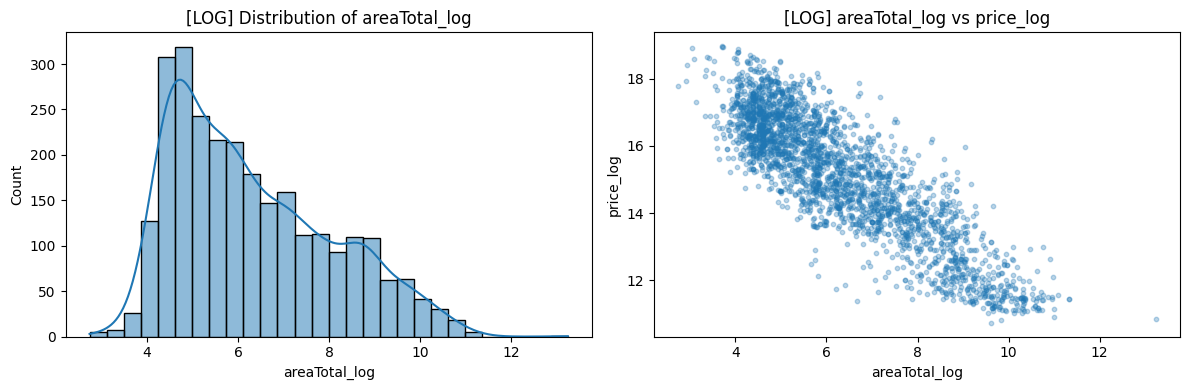

[LOG] feature: areaLegal_log
count    2706.000000
mean        6.236162
std         1.750028
min         2.734368
25%         4.792064
50%         5.797272
75%         7.435662
max        13.239572
Name: areaLegal_log, dtype: float64
Skewness:  0.704


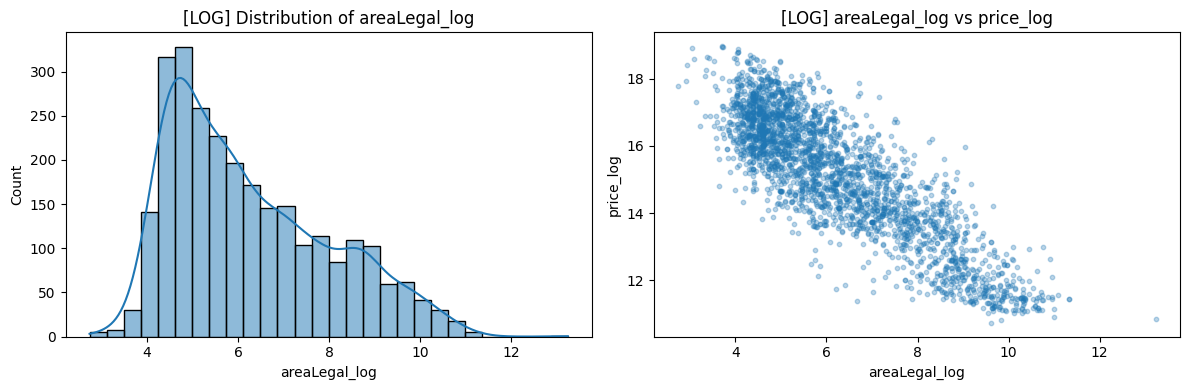

[LOG] feature: areaTotalWidth_log
count    2706.000000
mean        2.573919
std         0.903311
min         0.631272
25%         1.791759
50%         2.350899
75%         3.223362
max         6.478510
Name: areaTotalWidth_log, dtype: float64
Skewness:  0.889


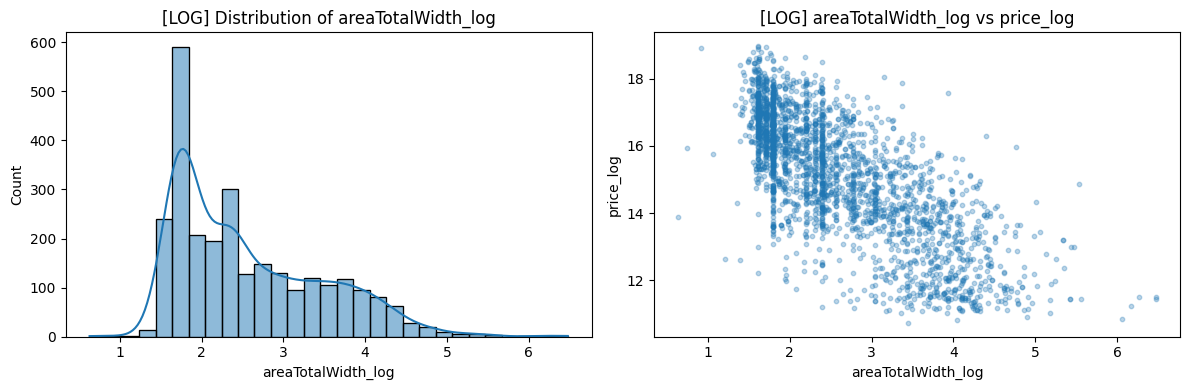

[LOG] feature: areaTotalLength_log
count    2706.000000
mean        3.822524
std         0.921337
min         1.427916
25%         3.085115
50%         3.652475
75%         4.386454
max         7.215637
Name: areaTotalLength_log, dtype: float64
Skewness:  0.742


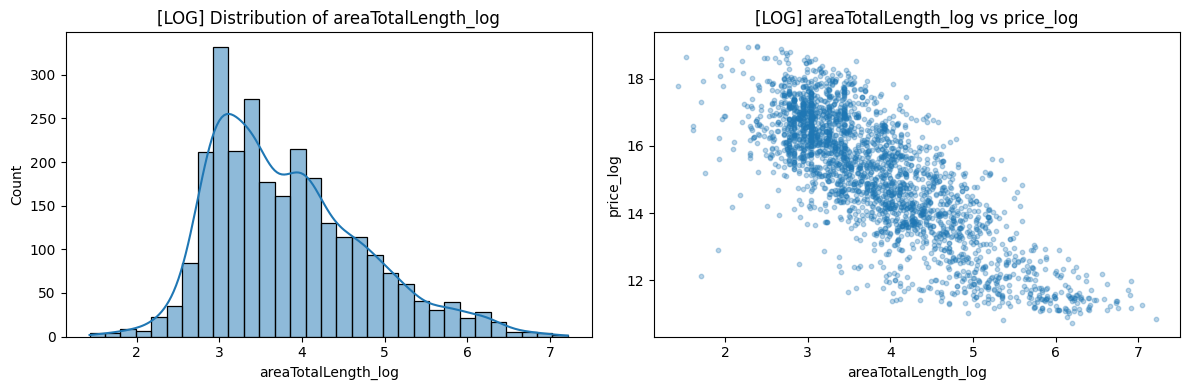

[LOG] feature: %Residential
count    2706.000000
mean        0.118820
std         0.234107
min         0.000000
25%         0.000000
50%         0.000000
75%         0.106811
max         1.000000
Name: %Residential, dtype: float64
Skewness:  2.110


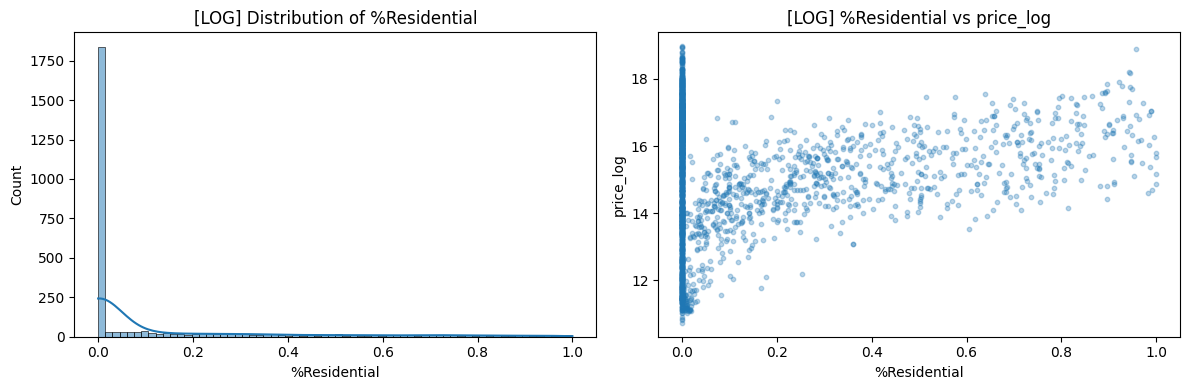

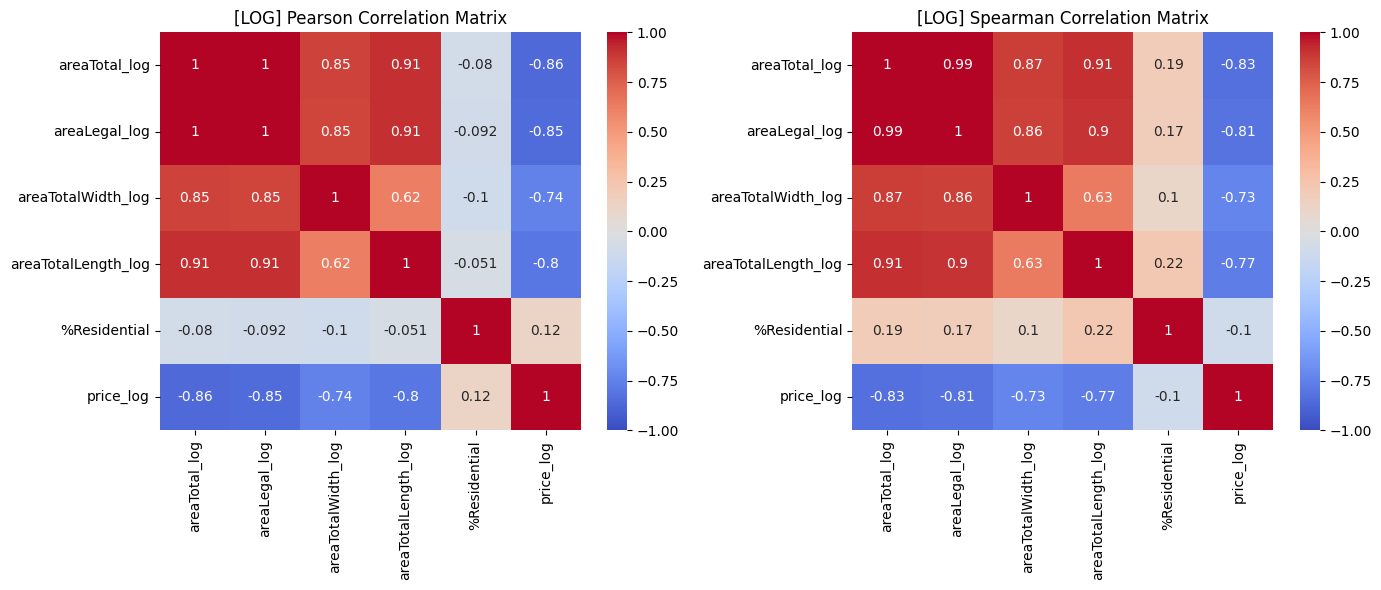

[STD] feature: areaTotal_std
count    2.706000e+03
mean    -1.050322e-17
std      1.000185e+00
min     -2.340574e-01
25%     -2.255070e-01
50%     -2.079178e-01
75%     -9.557191e-02
max      4.351302e+01
Name: areaTotal_std, dtype: float64
Skewness:  31.262


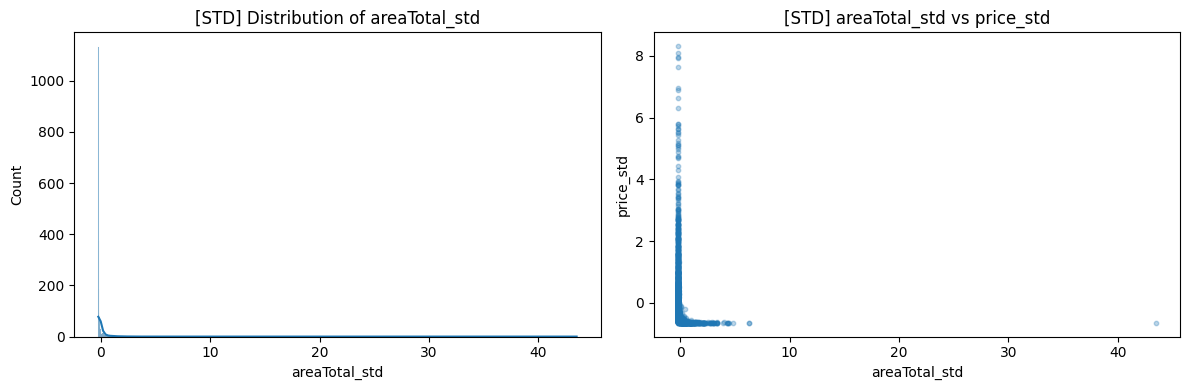

[STD] feature: areaLegal_std
count    2.706000e+03
mean    -5.251609e-18
std      1.000185e+00
min     -2.298856e-01
25%     -2.216974e-01
50%     -2.054340e-01
75%     -9.906147e-02
max      4.354649e+01
Name: areaLegal_std, dtype: float64
Skewness:  31.332


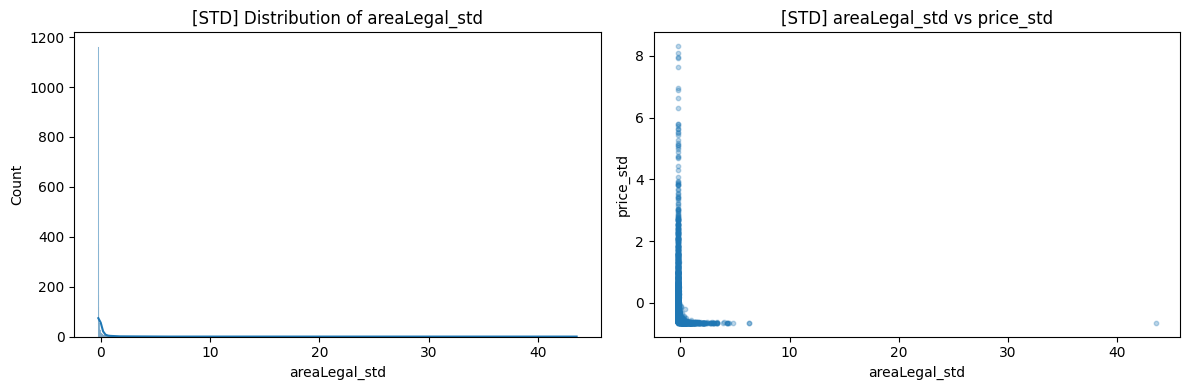

[STD] feature: areaTotalWidth_std
count    2.706000e+03
mean     2.625805e-17
std      1.000185e+00
min     -5.694824e-01
25%     -4.517791e-01
50%     -3.233625e-01
75%      9.424140e-02
max      1.797507e+01
Name: areaTotalWidth_std, dtype: float64
Skewness:  8.298


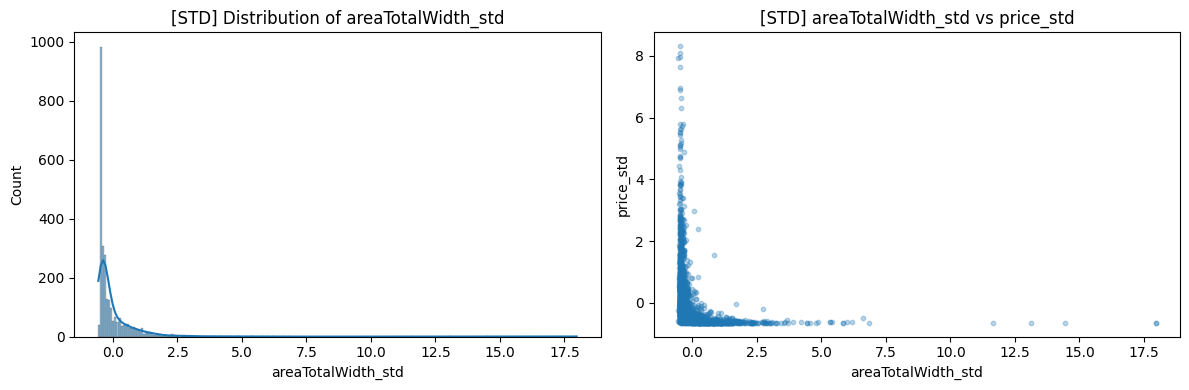

[STD] feature: areaTotalLength_std
count    2.706000e+03
mean    -5.251609e-17
std      1.000185e+00
min     -6.513384e-01
25%     -4.919306e-01
50%     -3.415290e-01
75%      3.479039e-02
max      1.156425e+01
Name: areaTotalLength_std, dtype: float64
Skewness:  4.292


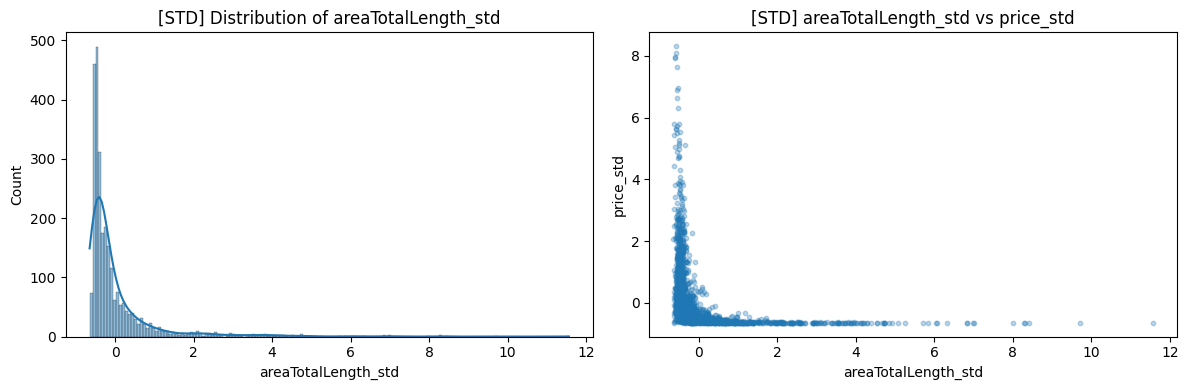

[STD] feature: %Residential_std
count    2.706000e+03
mean     5.776770e-17
std      1.000185e+00
min     -5.076384e-01
25%     -5.076384e-01
50%     -5.076384e-01
75%     -5.130573e-02
max      3.764708e+00
Name: %Residential_std, dtype: float64
Skewness:  2.110


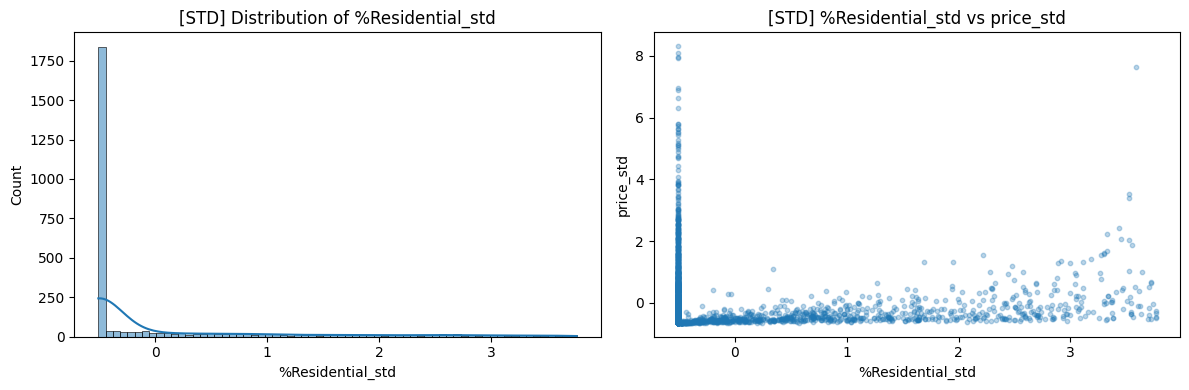

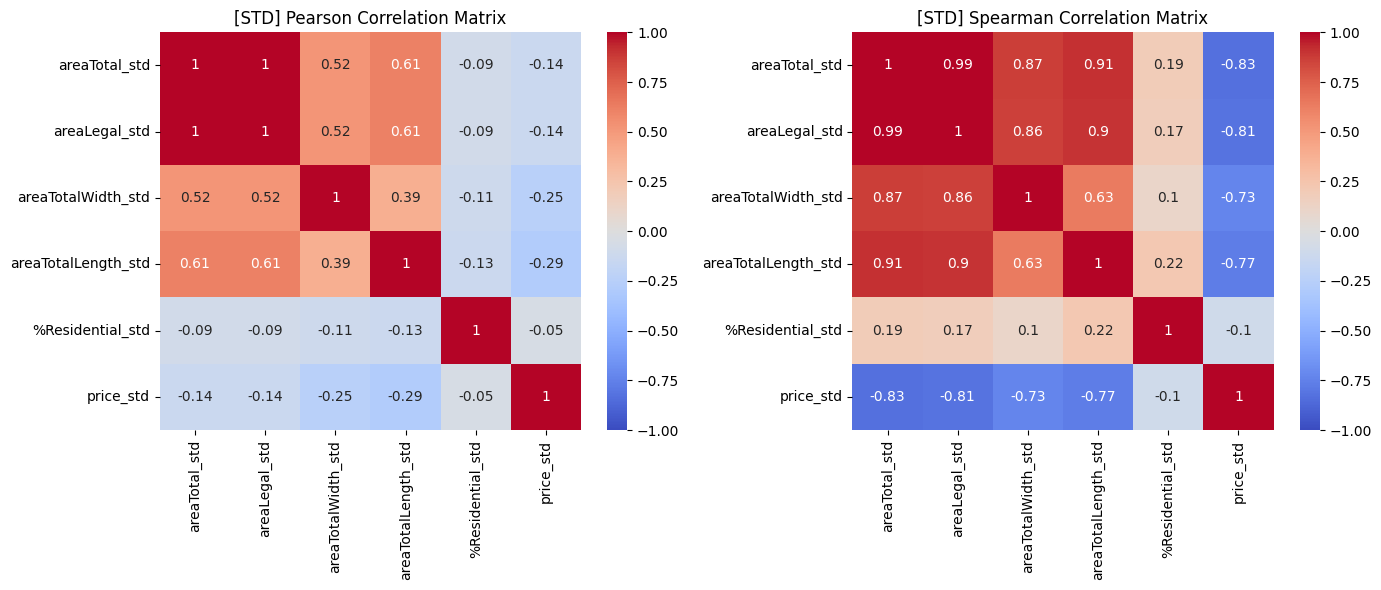

[ROBUST] feature: areaTotal_robust
count    2706.000000
mean        1.600167
std         7.697576
min        -0.201174
25%        -0.135369
50%         0.000000
75%         0.864631
max       336.483021
Name: areaTotal_robust, dtype: float64
Skewness:  31.262


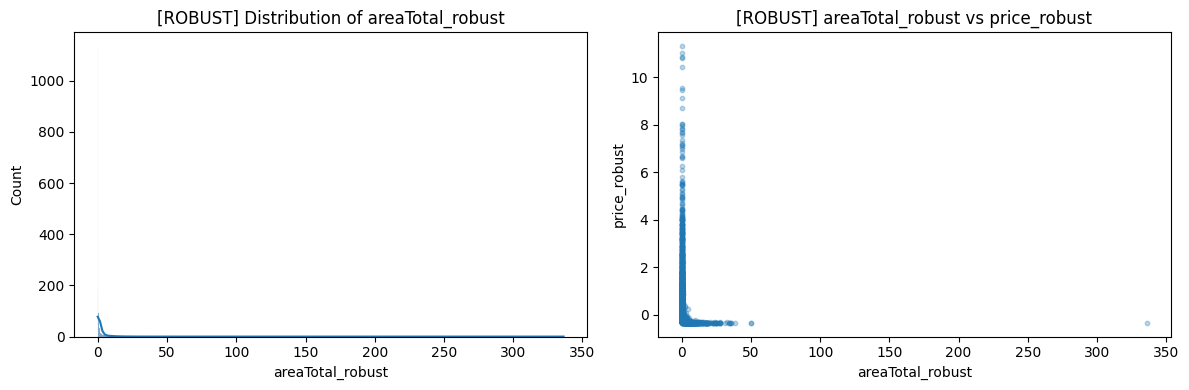

[ROBUST] feature: areaLegal_robust
count    2.706000e+03
mean     1.675153e+00
std      8.155722e+00
min     -1.993841e-01
25%     -1.326158e-01
50%      1.805197e-17
75%      8.673842e-01
max      3.567626e+02
Name: areaLegal_robust, dtype: float64
Skewness:  31.332


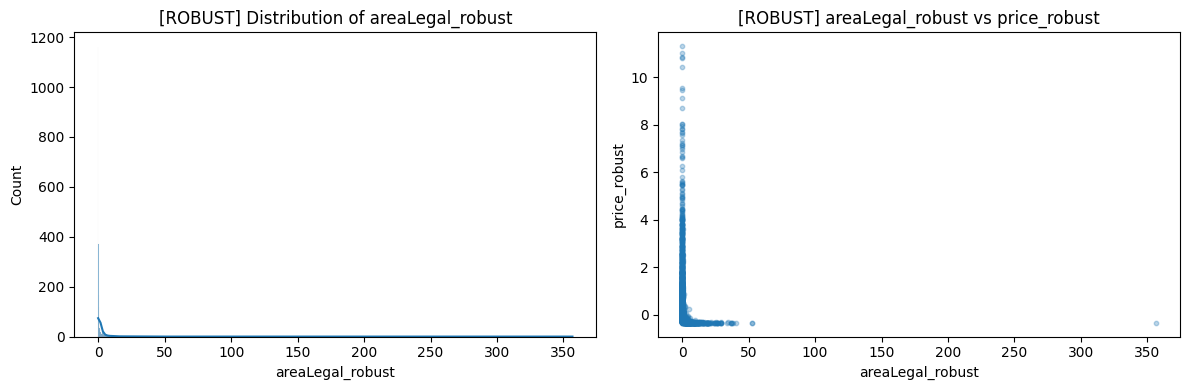

[ROBUST] feature: areaTotalWidth_robust
count    2.706000e+03
mean     5.922168e-01
std      1.831772e+00
min     -4.507521e-01
25%     -2.351864e-01
50%     -4.645806e-17
75%      7.648136e-01
max      3.351236e+01
Name: areaTotalWidth_robust, dtype: float64
Skewness:  8.298


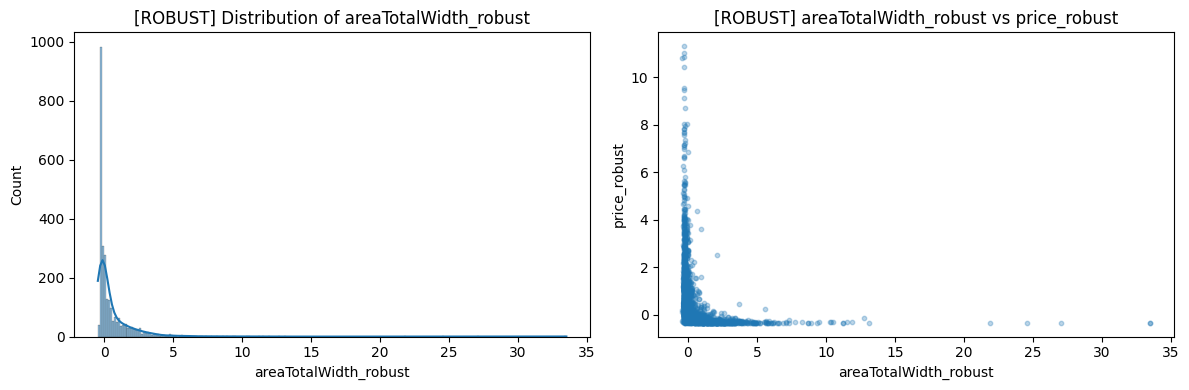

[ROBUST] feature: areaTotalLength_robust
count    2706.000000
mean        0.648406
std         1.898889
min        -0.588185
25%        -0.285543
50%         0.000000
75%         0.714457
max        22.603574
Name: areaTotalLength_robust, dtype: float64
Skewness:  4.292


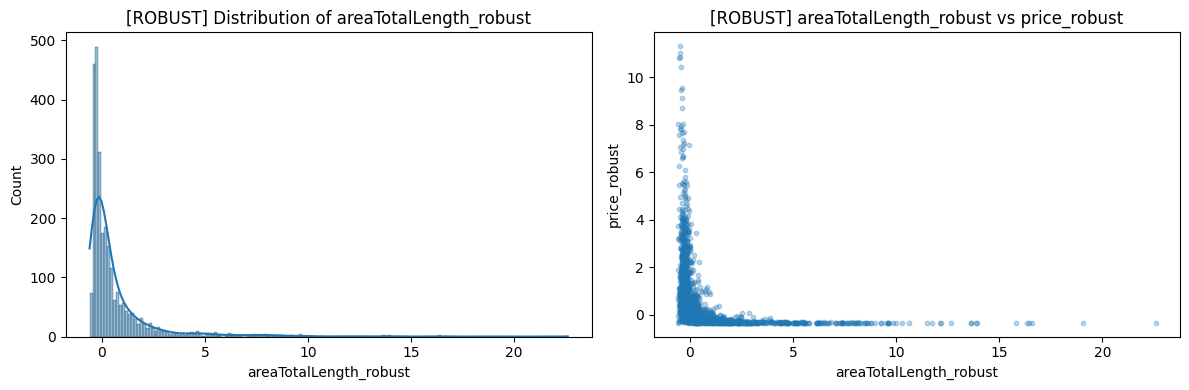

[ROBUST] feature: %Residential_robust
count    2706.000000
mean        1.112431
std         2.191789
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         9.362351
Name: %Residential_robust, dtype: float64
Skewness:  2.110


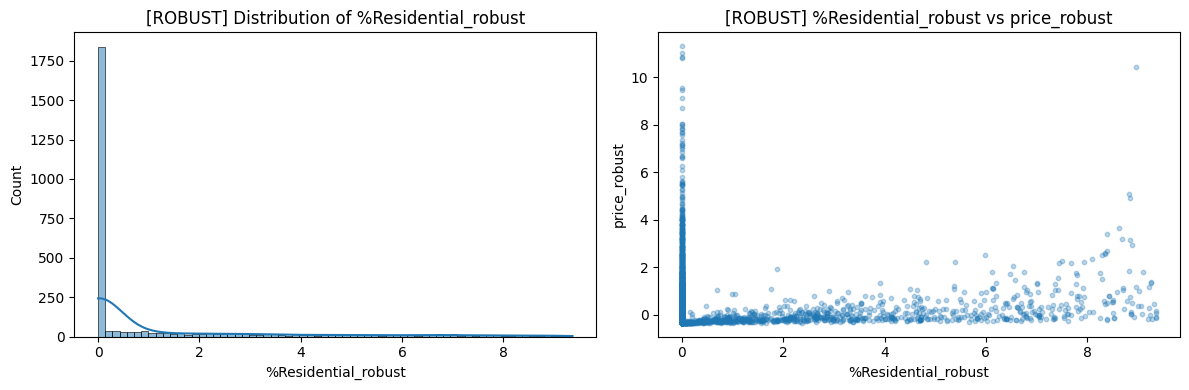

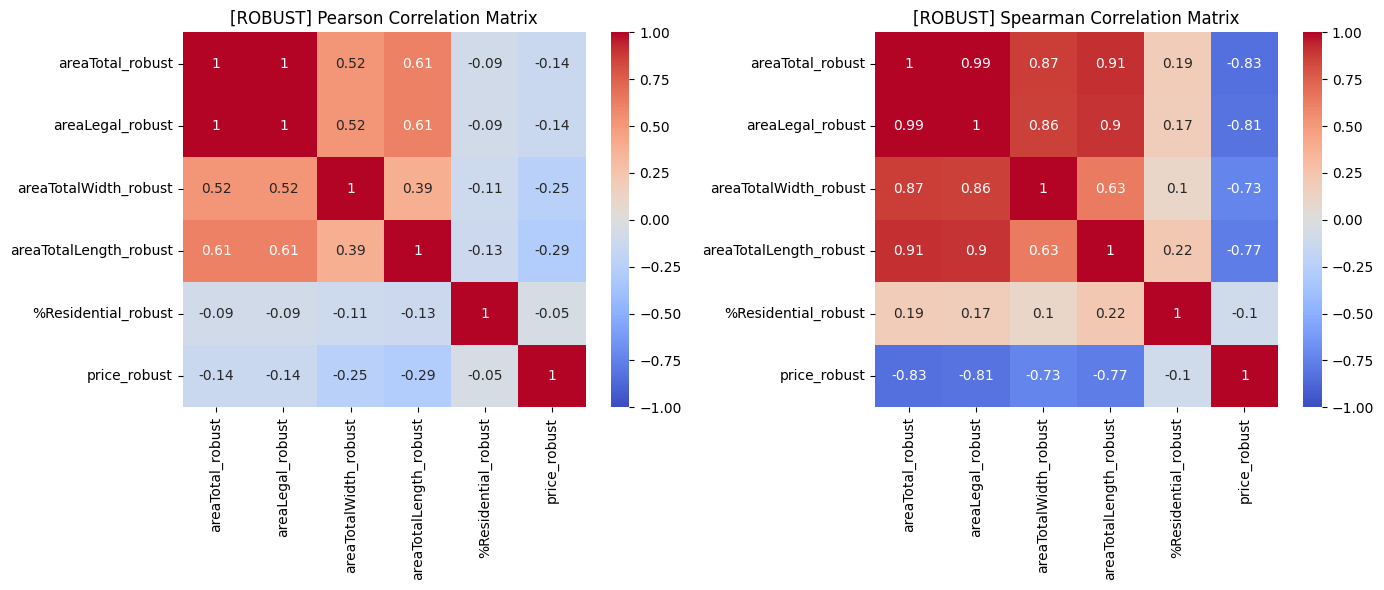

[LOG_STD] feature: areaTotal_log_std
count    2.706000e+03
mean    -1.155354e-16
std      1.000185e+00
min     -2.040070e+00
25%     -8.382444e-01
50%     -2.470454e-01
75%      6.881507e-01
max      3.983098e+00
Name: areaTotal_log_std, dtype: float64
Skewness:  0.660


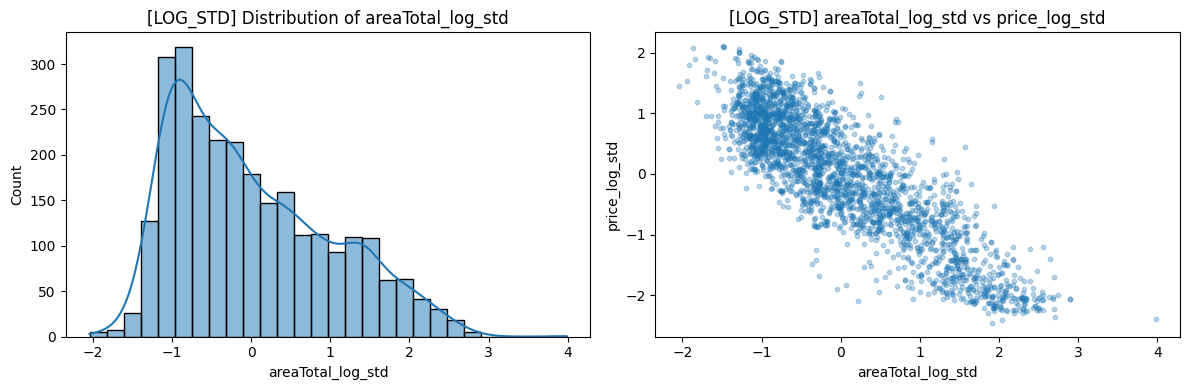

[LOG_STD] feature: areaLegal_log_std
count    2.706000e+03
mean    -5.251609e-17
std      1.000185e+00
min     -2.001363e+00
25%     -8.253380e-01
50%     -2.508366e-01
75%      6.855438e-01
max      4.002623e+00
Name: areaLegal_log_std, dtype: float64
Skewness:  0.704


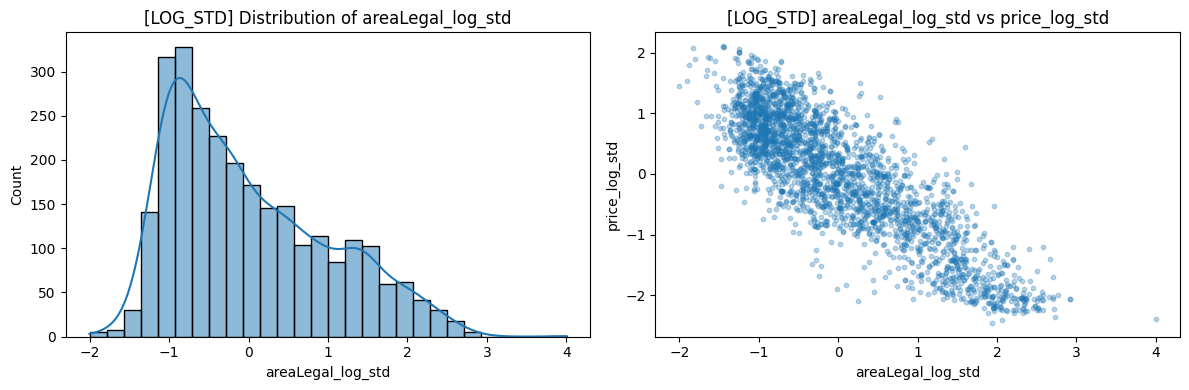

[LOG_STD] feature: areaTotalWidth_log_std
count    2.706000e+03
mean     8.402575e-17
std      1.000185e+00
min     -2.150983e+00
25%     -8.660408e-01
50%     -2.469374e-01
75%      7.190922e-01
max      4.323333e+00
Name: areaTotalWidth_log_std, dtype: float64
Skewness:  0.889


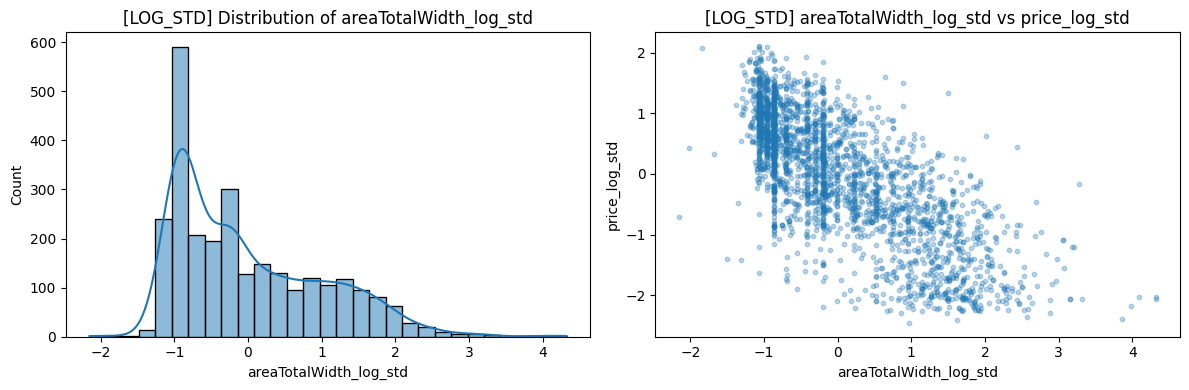

[LOG_STD] feature: areaTotalLength_log_std
count    2.706000e+03
mean     3.045933e-16
std      1.000185e+00
min     -2.599539e+00
25%     -8.005171e-01
50%     -1.846023e-01
75%      6.121910e-01
max      3.683495e+00
Name: areaTotalLength_log_std, dtype: float64
Skewness:  0.742


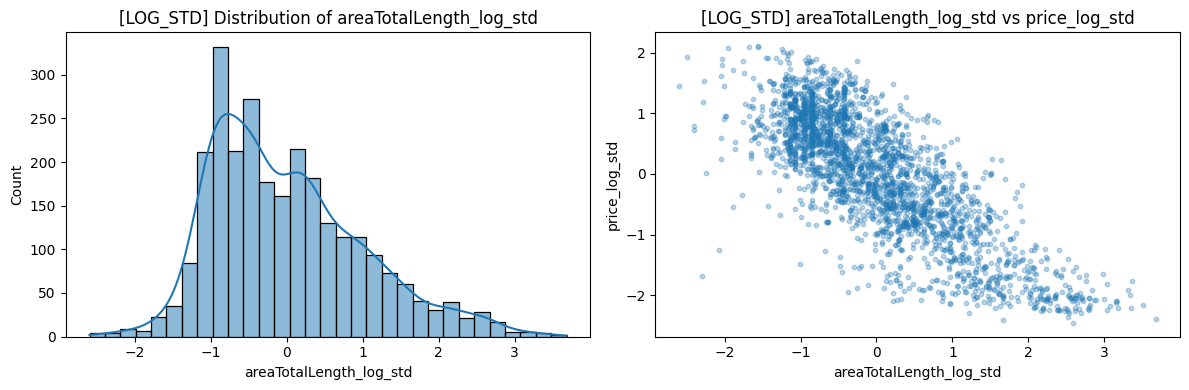

[LOG_STD] feature: %Residential_log_std
count    2.706000e+03
mean     5.776770e-17
std      1.000185e+00
min     -5.076384e-01
25%     -5.076384e-01
50%     -5.076384e-01
75%     -5.130573e-02
max      3.764708e+00
Name: %Residential_log_std, dtype: float64
Skewness:  2.110


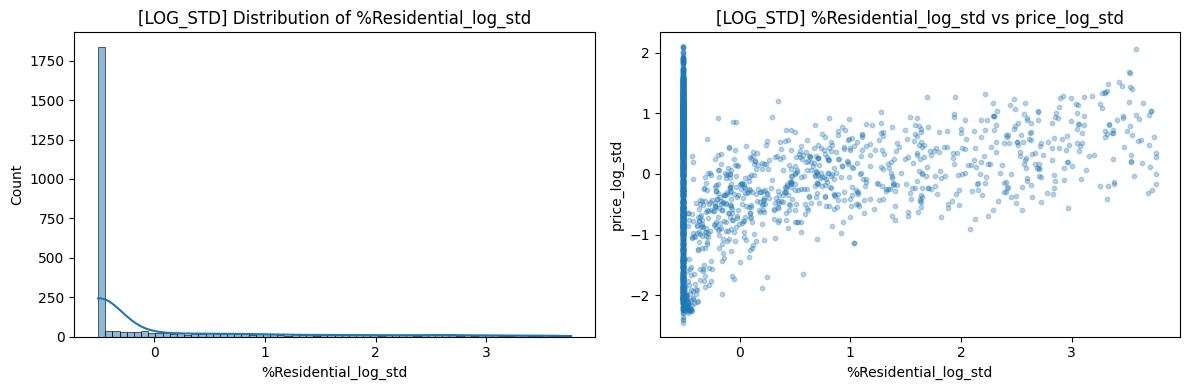

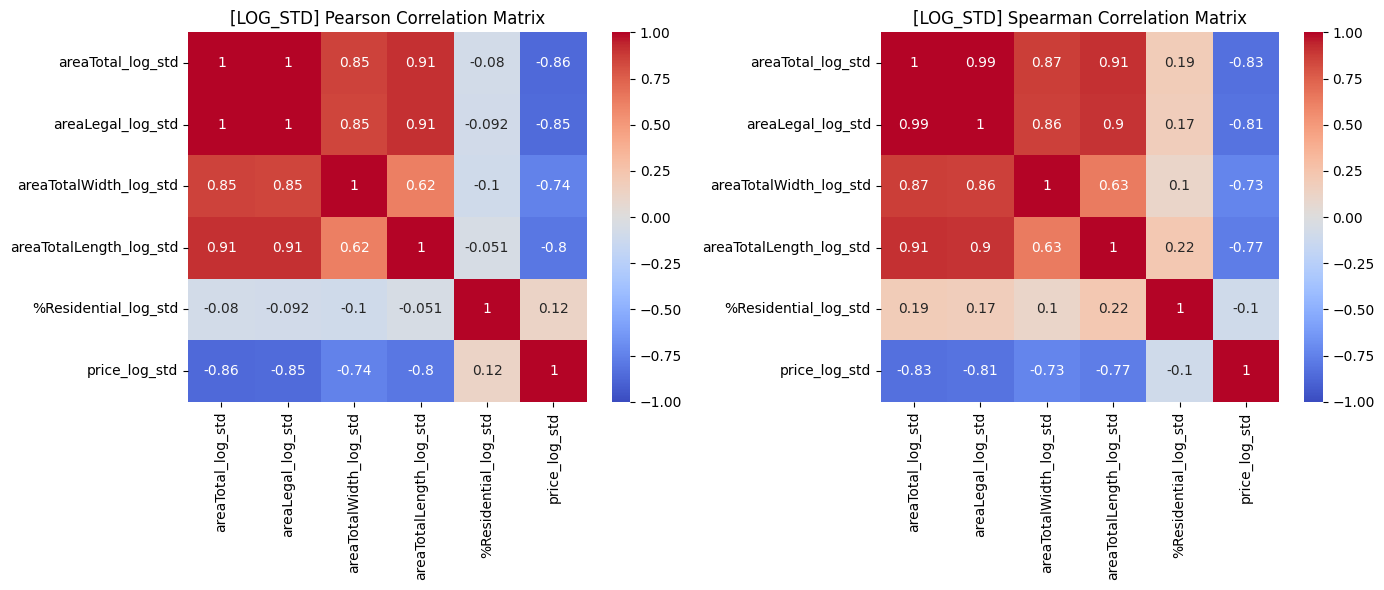

  Feature  N_categories  N_missing  ANOVA p-value  Kruskal p-value  Eta-squared
     ward           437          0   4.330675e-68    1.800424e-148     0.376115
 landType             9          0  7.016971e-185     0.000000e+00     0.278421
houseType             4          0  1.331676e-174    2.425944e-128     0.258146
 district            85         73  1.086381e-109    1.092569e-145     0.252407
 province            23          0   2.794407e-34     1.132800e-22     0.077887
 location             2          3   1.537091e-20     2.529387e-56     0.031449


In [49]:
# ==========================================
# EDA BIẾN LIÊN TỤC
# ==========================================

# ==========================================
# NHÁNH A: LOG (giữ nguyên như cũ)
# ==========================================
log_cols_map = {
    "areaTotal": "areaTotal_log",
    "areaLegal": "areaLegal_log",
    "areaTotalWidth": "areaTotalWidth_log",
    "areaTotalLength": "areaTotalLength_log",
    "unitpriceEstimatedByStaff": "price_log",
}
for raw_col, log_col in log_cols_map.items():
    df_0_eda[log_col] = np.log1p(df_0_eda[raw_col])  # log1p = ln(1 + x)

feat_log = [c for c in log_cols_map.values() if c != "price_log"] + ["%Residential"]
target_log = "price_log"

# ==========================================
# NHÁNH B: STANDARDSCALER (trên giá trị gốc)
# ==========================================
std_cols_map = {
    "areaTotal": "areaTotal_std",
    "areaLegal": "areaLegal_std",
    "areaTotalWidth": "areaTotalWidth_std",
    "areaTotalLength": "areaTotalLength_std",
    "%Residential": "%Residential_std",
    "unitpriceEstimatedByStaff": "price_std",
}
scaler = StandardScaler()
df_0_eda[list(std_cols_map.values())] = scaler.fit_transform(
    df_0_eda[list(std_cols_map.keys())]
)

feat_std = [c for c in std_cols_map.values() if c != "price_std"]
target_std = "price_std"

# ==========================================
# NHÁNH C: ROBUSTSCALER (trên giá trị gốc)
# ==========================================
robust_cols_map = {
    "areaTotal": "areaTotal_robust",
    "areaLegal": "areaLegal_robust",
    "areaTotalWidth": "areaTotalWidth_robust",
    "areaTotalLength": "areaTotalLength_robust",
    "%Residential": "%Residential_robust",
    "unitpriceEstimatedByStaff": "price_robust",
}
scaler = RobustScaler()
df_0_eda[list(robust_cols_map.values())] = scaler.fit_transform(
    df_0_eda[list(robust_cols_map.keys())]
)

feat_robust = [c for c in robust_cols_map.values() if c != "price_robust"]
target_robust = "price_robust"

# ==========================================
# NHÁNH D: LOG rồi mới SCALE (đúng pipeline đã thống nhất — log trước, scaler sau)
# ==========================================
log_std_cols_map = {
    "areaTotal_log": "areaTotal_log_std",
    "areaLegal_log": "areaLegal_log_std",
    "areaTotalWidth_log": "areaTotalWidth_log_std",
    "areaTotalLength_log": "areaTotalLength_log_std",
    "%Residential": "%Residential_log_std",
    # không log vì đã trong [0,1] nhưng đổi tên để phân biệt, gần chuẩn
    "price_log": "price_log_std",
}
scaler_log_std = StandardScaler()
df_0_eda[list(log_std_cols_map.values())] = scaler_log_std.fit_transform(
    df_0_eda[
        list(log_std_cols_map.keys())
    ]  # <-- lấy INPUT là cột ĐÃ LOG (Nhánh A), không phải cột gốc
)

feat_log_std = [c for c in log_std_cols_map.values() if c != "price_log_std"]
target_log_std = "price_log_std"


# ==========================================
# HÀM EDA DÙNG CHUNG
# ==========================================
def eda_plots(df, feature_cols, target_col, tag):
    for col in feature_cols:
        print(f"[{tag}] feature: {col}")
        print(df[col].describe())
        print(f"Skewness: {df[col].skew(): .3f}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f"[{tag}] Distribution of {col}")

        axes[1].scatter(df[col], df[target_col], alpha=0.3, s=10)
        axes[1].set_xlabel(col)
        axes[1].set_ylabel(target_col)
        axes[1].set_title(f"[{tag}] {col} vs {target_col}")
        plt.tight_layout()
        plt.show()

    corr_cols = feature_cols + [target_col]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, method in zip(axes, ["pearson", "spearman"]):
        sns.heatmap(
            df[corr_cols].corr(method=method),
            annot=True,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            ax=ax,
        )
        ax.set_title(f"[{tag}] {method.capitalize()} Correlation Matrix")
    plt.tight_layout()
    plt.show()


eda_plots(df_0_eda, feat_log, target_log, tag="LOG")
eda_plots(df_0_eda, feat_std, target_std, tag="STD")
eda_plots(df_0_eda, feat_robust, target_robust, tag="ROBUST")
eda_plots(df_0_eda, feat_log_std, target_log_std, tag="LOG_STD")

# ==========================================
# EDA BIẾN PHÂN LOẠI — ANOVA/Kruskal-Wallis + Eta-squared
# ==========================================
categorical_cols = [
    "landType",
    "houseType",
    "province",
    "ward",
    "district",
    "location",
]


def eta_squared(df, cat_col, target_col):
    groups = [g[target_col].values for _, g in df.groupby(cat_col)]
    grand_mean = df[target_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = sum((df[target_col] - grand_mean) ** 2)
    return ss_between / ss_total


eda_cat_results = []
for col in categorical_cols:
    n_missing = df_0_eda[col].isnull().sum()
    n_categories = df_0_eda[col].nunique()

    groups = [g["unitpriceEstimatedByStaff"].values for _, g in df_0_eda.groupby(col)]
    f_stat, p_anova = f_oneway(*groups)
    h_stat, p_kruskal = kruskal(*groups)
    eta2 = eta_squared(df_0_eda, col, "unitpriceEstimatedByStaff")
    eda_cat_results.append(
        {
            "Feature": col,
            "N_categories": n_categories,
            "N_missing": n_missing,
            "ANOVA p-value": p_anova,
            "Kruskal p-value": p_kruskal,
            "Eta-squared": eta2,
        }
    )

eda_cat_df = pd.DataFrame(eda_cat_results).sort_values("Eta-squared", ascending=False)
print(eda_cat_df.to_string(index=False))

In [50]:
# ==========================================
# KIỂM TRA NESTING: 1 tên "ward" có thuộc về nhiều "province" khác nhau không?
# ==========================================
# groupby("ward")["province"].nunique() -> với mỗi tên ward, đếm số province KHÁC NHAU
# mà tên ward đó xuất hiện trong dữ liệu.
# Nếu dữ liệu hành chính "sạch" (nesting đúng: ward chỉ thuộc 1 province duy nhất),
# kết quả phải luôn = 1 cho mọi ward.

# .value_counts() -> đếm xem có bao nhiêu ward ứng với mỗi giá trị "số province" đó
# (vd. có bao nhiêu ward chỉ thuộc 1 province, bao nhiêu ward thuộc 2 province, ...)
print(df_0_eda.groupby("ward")["province"].nunique().value_counts())

# Diễn giải kết quả:
# - Giá trị "1" chiếm đa số -> đa phần ward là bình thường, chỉ thuộc đúng 1 province
# - Có giá trị > 1 (2, 3, 4, 5, 6...) -> CẢNH BÁO: cùng 1 tên ward đang xuất hiện
#   ở nhiều province khác nhau. Nguyên nhân khả năng cao: trùng tên hành chính
#   (vd. "Phường 1" xuất hiện ở nhiều quận/huyện/tỉnh khác nhau, không phải
#   cùng 1 địa điểm thực tế) -> groupby("ward") đơn thuần đang GỘP NHẦM
#   nhiều địa điểm khác nhau thành 1 nhóm.
# -> Ảnh hưởng trực tiếp tới ward_encoded (OOF target encoding) vì nó đang
#    group theo đúng "ward" đơn lẻ này, có thể trộn lẫn giá của các khu vực
#    khác nhau vào chung 1 giá trị encode.

# ==========================================
# KIỂM TRA MỨC ĐỘ NGHIÊM TRỌNG: bao nhiêu % SỐ DÒNG DỮ LIỆU (không phải số ward)
# đang bị ảnh hưởng bởi lỗi trùng tên này
# ==========================================
# Lấy danh sách các ward bị trùng tên (xuất hiện ở > 1 province)
affected_wards = df_0_eda.groupby("ward")["province"].nunique()
affected_wards = affected_wards[affected_wards > 1].index

# .isin(affected_wards) -> đánh dấu True cho mỗi DÒNG dữ liệu thuộc 1 trong các ward bị trùng tên
# .mean() -> vì True/False được tính như 1/0, mean() chính là TỶ LỆ % dòng bị ảnh hưởng
# (khác với đếm SỐ WARD bị trùng ở bước trên — ở đây đếm theo SỐ DÒNG, phản ánh đúng
# mức độ ảnh hưởng thực tế lên dữ liệu, vì 1 ward phổ biến có thể chiếm rất nhiều dòng)
pct_rows_affected = df_0_eda["ward"].isin(affected_wards).mean() * 100
print(f"% dòng dữ liệu thuộc nhóm ward bị trùng tên: {pct_rows_affected:.1f}%")

zero_province_wards = df_0_eda.groupby("ward")["province"].nunique()
zero_province_wards = zero_province_wards[zero_province_wards == 0].index
print(
    "Số dòng bị ảnh hưởng bởi province thiếu:",
    df_0_eda["ward"].isin(zero_province_wards).sum(),
)
print("Tổng số dòng có province NaN trong toàn dataset:", df_0_eda["province"].isna().sum())

province
1    392
2     33
3      7
4      3
5      2
Name: count, dtype: int64
% dòng dữ liệu thuộc nhóm ward bị trùng tên: 37.4%
Số dòng bị ảnh hưởng bởi province thiếu: 0
Tổng số dòng có province NaN trong toàn dataset: 0


In [51]:
# ==========================================
# BƯỚC 1: TÁCH TRAIN/TEST
# ==========================================
df_train, df_test = train_test_split(df_0, test_size=0.2, random_state=42)
df_train = df_train.copy()
df_test = df_test.copy()

# ==========================================
# BƯỚC 2: XỬ LÝ MISSING TRƯỚC KHI ENCODE
# (district: 73 NaN, location: 3 NaN — theo EDA, fill "Unknown" thay vì drop dòng,
#  vì đây là missing thật do đặc điểm địa chỉ 2 cấp mới, không phải lỗi)
# ==========================================
# Tính mode CHỈ trên train của location
location_mode = df_train["location"].mode()[0]
for df in [df_train, df_test]:
    df["district"] = df["district"].fillna("Unknown")
    df["location"] = df["location"].fillna(location_mode)

# ==========================================
# BƯỚC 3: GMM PHÂN CỤM DIỆN TÍCH — fit CHỈ trên train
# ==========================================
df_train["area_log"] = np.log1p(df_train["areaTotal"])
df_test["area_log"] = np.log1p(df_test["areaTotal"])

gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
gmm.fit(df_train[["area_log"]])

df_train["cluster_raw"] = gmm.predict(df_train[["area_log"]])
df_test["cluster_raw"] = gmm.predict(df_test[["area_log"]])

sorted_indices = np.argsort(gmm.means_.flatten())
cluster_mapping = {old: new for new, old in enumerate(sorted_indices)}
df_train["area_segment_gmm"] = df_train["cluster_raw"].map(cluster_mapping).astype(int)
df_test["area_segment_gmm"] = df_test["cluster_raw"].map(cluster_mapping).astype(int)

df_train.drop(columns=["area_log", "cluster_raw"], inplace=True)
df_test.drop(columns=["area_log", "cluster_raw"], inplace=True)

# ==========================================
# BƯỚC 4: TẠO FOLD SPLITS 1 LẦN DUY NHẤT — dùng chung cho MỌI OOF encoding phía sau
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_splits = list(skf.split(df_train, df_train["area_segment_gmm"]))

# ==========================================
# BƯỚC 5: TARGET + LOC_SEGMENT (ward+province+segment) — OOF, dùng fold_splits chung
# ==========================================
df_train["loc_segment"] = (
    df_train["ward"].astype(str)
    + "_"
    + df_train["province"].astype(str)
    + "_"
    + df_train["area_segment_gmm"].astype(str)
)
df_test["loc_segment"] = (
    df_test["ward"].astype(str)
    + "_"
    + df_test["province"].astype(str)
    + "_"
    + df_test["area_segment_gmm"].astype(str)
)

df_train["target_log"] = np.log1p(df_train["unitpriceEstimatedByStaff"])
df_test["target_log"] = np.log1p(df_test["unitpriceEstimatedByStaff"])

df_train["target_enc_loc_seg"] = np.nan
for train_idx, val_idx in fold_splits:
    fold_train = df_train.iloc[train_idx]
    stats = fold_train.groupby("loc_segment")["target_log"].median()
    df_train.iloc[val_idx, df_train.columns.get_loc("target_enc_loc_seg")] = (
        df_train.iloc[val_idx]["loc_segment"].map(stats)
    )

global_median = df_train["target_log"].median()
df_train["target_enc_loc_seg"] = df_train["target_enc_loc_seg"].fillna(global_median)

full_train_stats = df_train.groupby("loc_segment")["target_log"].median()
df_test["target_enc_loc_seg"] = (
    df_test["loc_segment"].map(full_train_stats).fillna(global_median)
)

# ==========================================
# BƯỚC 6: WARD_ENCODED — SỬA ĐÚNG NGAY TỪ ĐẦU: key = ward+province (không dùng ward đơn lẻ)
# Lý do: 37.4% dòng có tên ward trùng giữa các province khác nhau (đã xác nhận qua nested check)
# ==========================================
df_train["ward_province_key"] = (
    df_train["ward"].astype(str) + "_" + df_train["province"].astype(str)
)
df_test["ward_province_key"] = (
    df_test["ward"].astype(str) + "_" + df_test["province"].astype(str)
)

df_train["ward_encoded"] = np.nan
for train_idx, val_idx in fold_splits:
    fold_train = df_train.iloc[train_idx]
    stats = fold_train.groupby("ward_province_key")["target_log"].median()
    df_train.iloc[val_idx, df_train.columns.get_loc("ward_encoded")] = df_train.iloc[
        val_idx
    ]["ward_province_key"].map(stats)
df_train["ward_encoded"] = df_train["ward_encoded"].fillna(global_median)

full_train_stats_ward = df_train.groupby("ward_province_key")["target_log"].median()
df_test["ward_encoded"] = (
    df_test["ward_province_key"].map(full_train_stats_ward).fillna(global_median)
)

# ==========================================
# BƯỚC 7: LABEL ENCODING (houseType, province, district)
# ==========================================
low_cardi_col = ["houseType", "province", "district"]
label_encoders = {}
for col in low_cardi_col:
    le = LabelEncoder()
    df_train[col + "_encoded"] = le.fit_transform(df_train[col].astype(str))
    known = set(le.classes_)
    df_test[col + "_encoded"] = (
        df_test[col]
        .astype(str)
        .apply(lambda x: le.transform([x])[0] if x in known else -1)
    )
    label_encoders[col] = le
df_train = df_train.drop(columns=low_cardi_col)
df_test = df_test.drop(columns=low_cardi_col)

# ==========================================
# BƯỚC 8: ONE-HOT (location, landType)
# ==========================================
very_low_cardi = ["location", "landType"]
df_train = pd.get_dummies(df_train, columns=very_low_cardi, drop_first=True)
df_test = pd.get_dummies(df_test, columns=very_low_cardi, drop_first=True)

for col in df_train.columns:
    if col not in df_test.columns:
        df_test[col] = 0
df_test = df_test[df_train.columns]

onehot_cols = [c for c in df_train.columns if c.startswith(("location_", "landType_"))]
df_train[onehot_cols] = df_train[onehot_cols].astype(int)
df_test[onehot_cols] = df_test[onehot_cols].astype(int)

# ==========================================
# BƯỚC 9: TẠO feature_cols — loại bỏ target, ID, cột trung gian, areaLegal (dư thừa, corr 0.99 với areaTotal)
# ==========================================
exclude_cols = [
    "target_log",
    "unitpriceEstimatedByStaff",
    "priceEstimatedByStaff",
    "id",
    "propertyId",
    "appraisalContractId",
    "certificateNo",
    "statusName",
    "certificateDate",
    "loc_segment",
    "ward",
    "ward_province_key",
    "areaLegal",
    "fullAddress",  # bỏ theo quyết định EDA — dư thừa với areaTotal
]
feature_cols = [c for c in df_train.columns if c not in exclude_cols]

X_train = df_train[feature_cols]
y_train_log = df_train["target_log"]
X_test = df_test[feature_cols]
y_test_log = df_test["target_log"]

# Kiểm tra cuối — không còn cột string nào sót
remaining_str_cols = X_train.select_dtypes(include="object").columns.tolist()
assert len(remaining_str_cols) == 0, f"Còn cột chưa encode: {remaining_str_cols}"
print("feature_cols:", feature_cols)
print("Số dòng train/test:", len(X_train), len(X_test))

feature_cols: ['areaTotal', 'areaTotalWidth', 'areaTotalLength', 'areaResidential', '%Residential', 'area_segment_gmm', 'target_enc_loc_seg', 'ward_encoded', 'houseType_encoded', 'province_encoded', 'district_encoded', 'location_h-front', 'landType_land-annual-crops', 'landType_land-aquaculture', 'landType_land-business', 'landType_land-forestry', 'landType_land-mixed', 'landType_land-perennial-crops', 'landType_land-residential', 'landType_land-used-for-trading-service']
Số dòng train/test: 2164 542


In [52]:
# ========== ĐỊNH NGHĨA TẤT CẢ MODELS (BASELINE) ==========
models = {
    # Linear Models
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=1.0, random_state=42),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42),
    # Tree-based Models
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
    ),
    'AdaBoost': AdaBoostRegressor(n_estimators=50, learning_rate=1.0, random_state=42),
    'Bagging': BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=10),
        n_estimators=10,
        random_state=42,
        n_jobs=-1,
    ),
    # Advanced Boosting
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    'CatBoost': CatBoostRegressor(
        iterations=100, learning_rate=0.1, depth=6, random_state=42, verbose=0
    ),
}

# ========== TRAIN VÀ ĐÁNH GIÁ TẤT CẢ MODELS ==========

print("BẮT ĐẦU TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH...\n")

BẮT ĐẦU TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH...



In [53]:
# ==========================================
# CÁC HÀM METRIC CHUẨN THẨM ĐỊNH GIÁ (IAAO)
# ==========================================


def pct_within_tolerance(y_actual, y_pred, tolerance=0.10):
    """PE10: % số hồ sơ có sai số tuyệt đối nằm trong biên độ cho phép (mặc định 10%)."""
    pct_error = np.abs(y_pred - y_actual) / y_actual
    return (pct_error <= tolerance).mean() * 100


def compute_cod(y_actual, y_pred):
    """
    COD (Coefficient of Dispersion): đo độ PHÂN TÁN của sai số quanh trung vị.
    - Bước 1: tính ratio = giá dự đoán / giá thực cho từng hồ sơ
    - Bước 2: lấy trung vị của các ratio (median_ratio) — đại diện mức lệch "điển hình"
    - Bước 3: tính độ lệch tuyệt đối của từng ratio so với trung vị
    - Bước 4: COD = trung bình độ lệch tuyệt đối / trung vị ratio, quy về %
    Chuẩn IAAO: COD < 15% (tài sản đồng nhất, vd nhà ở), < 20% (tài sản không đồng nhất, vd đất lớn/thương mại).
    COD càng thấp = model càng nhất quán, ít hồ sơ bị lệch xa so với mức lệch chung.
    """
    ratio = y_pred / y_actual
    median_ratio = np.median(ratio)
    avg_abs_dev = np.mean(np.abs(ratio - median_ratio))
    return 100 * avg_abs_dev / median_ratio


def compute_prd(y_actual, y_pred):
    """
    PRD (Price-Related Differential): đo độ THIÊN LỆCH giữa tài sản giá cao và giá thấp.
    - Mean ratio: trung bình cộng đơn giản các ratio (mỗi hồ sơ đóng góp như nhau)
    - Weighted mean ratio: tổng dự đoán / tổng thực tế (hồ sơ giá trị lớn đóng góp nhiều hơn)
    - PRD = Mean ratio / Weighted mean ratio
    Chuẩn IAAO: PRD trong khoảng 0.98–1.03.
    - PRD > 1.03: model có xu hướng ĐỊNH GIÁ THẤP cho tài sản giá trị cao (regressive) — đúng rủi ro
      bạn từng lo ở phần bàn về clipping outlier trước đó.
    - PRD < 0.98: model có xu hướng ĐỊNH GIÁ CAO cho tài sản giá trị cao (progressive).
    """
    ratio = y_pred / y_actual
    mean_ratio = np.mean(ratio)
    weighted_mean_ratio = np.sum(y_pred) / np.sum(y_actual)
    return mean_ratio / weighted_mean_ratio


# ==========================================
# VÒNG LẶP ĐÁNH GIÁ ĐẦY ĐỦ — 12 MODEL x TOÀN BỘ METRIC
# ==========================================
results = []

for name, model in models.items():
    start = time.time()

    # ---- (1) Vòng CV thủ công, dùng fold_splits chung đã tạo trước đó ----
    # Mục đích: vừa lấy R² từng fold (đánh giá model theo cách cũ),
    # vừa gom OOF prediction (mỗi dòng train được dự đoán đúng 1 lần, bởi model
    # KHÔNG được train trên chính dòng đó) để tính sai số thực tế đáng tin cậy.
    oof_pred_log = np.zeros(len(X_train))
    fold_r2 = []
    for train_idx, val_idx in fold_splits:
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
        model.fit(X_tr, y_tr)
        pred_val = model.predict(X_val)
        oof_pred_log[val_idx] = pred_val
        fold_r2.append(r2_score(y_val, pred_val))
    cv_scores = np.array(fold_r2)

    # ---- (2) Quy đổi OOF prediction từ log-scale về đơn giá thực (VNĐ/m²) ----
    # np.expm1 là phép nghịch đảo của np.log1p đã dùng lúc tạo target_log
    oof_pred_real = np.expm1(oof_pred_log)
    oof_actual_real = df_train["unitpriceEstimatedByStaff"].values

    # ---- (3) Tính toàn bộ metric trên OOF (đại diện train, đáng tin hơn vì dùng hết 100% train) ----
    oof_mape = mean_absolute_percentage_error(oof_actual_real, oof_pred_real) * 100
    oof_rmse = np.sqrt(mean_squared_error(oof_actual_real, oof_pred_real))
    oof_mae = mean_absolute_error(oof_actual_real, oof_pred_real)
    oof_pe10 = pct_within_tolerance(oof_actual_real, oof_pred_real, 0.10)
    oof_cod = compute_cod(oof_actual_real, oof_pred_real)
    oof_prd = compute_prd(oof_actual_real, oof_pred_real)

    # ---- (4) Fit lại trên TOÀN BỘ train (không chia fold nữa), để đánh giá trên TEST thật ----
    model.fit(X_train, y_train_log)
    train_r2 = r2_score(y_train_log, model.predict(X_train))
    test_pred_log = model.predict(X_test)
    test_r2 = r2_score(y_test_log, test_pred_log)

    # ---- (5) Quy đổi TEST prediction về đơn giá thực, tính metric tương tự OOF ----
    test_pred_real = np.expm1(test_pred_log)
    test_actual_real = df_test["unitpriceEstimatedByStaff"].values

    test_mape = mean_absolute_percentage_error(test_actual_real, test_pred_real) * 100
    test_rmse = np.sqrt(mean_squared_error(test_actual_real, test_pred_real))
    test_mae = mean_absolute_error(test_actual_real, test_pred_real)
    test_pe10 = pct_within_tolerance(test_actual_real, test_pred_real, 0.10)
    test_cod = compute_cod(test_actual_real, test_pred_real)
    test_prd = compute_prd(test_actual_real, test_pred_real)

    # ---- (6) Gom toàn bộ kết quả của model này vào 1 dòng ----
    results.append(
        {
            "Model": name,
            "CV R2 Mean": cv_scores.mean(),
            "CV R2 Std": cv_scores.std(),
            "Train R2": train_r2,
            "Test R2": test_r2,
            "CV Overfit": train_r2 - cv_scores.mean(),
            "OOF MAPE (%)": oof_mape,
            "OOF RMSE": oof_rmse,
            "OOF MAE": oof_mae,
            "OOF PE10 (%)": oof_pe10,
            "OOF COD": oof_cod,
            "OOF PRD": oof_prd,
            "Test MAPE (%)": test_mape,
            "Test RMSE": test_rmse,
            "Test MAE": test_mae,
            "Test PE10 (%)": test_pe10,
            "Test COD": test_cod,
            "Test PRD": test_prd,
            "Time (s)": round(time.time() - start, 2),
        }
    )

results_df = pd.DataFrame(results).sort_values("CV R2 Mean", ascending=False)
print(results_df.to_string(index=False))

            Model  CV R2 Mean  CV R2 Std  Train R2  Test R2  CV Overfit  OOF MAPE (%)     OOF RMSE      OOF MAE  OOF PE10 (%)    OOF COD  OOF PRD  Test MAPE (%)    Test RMSE     Test MAE  Test PE10 (%)   Test COD  Test PRD  Time (s)
         LightGBM    0.885914   0.007054  0.948404 0.883209    0.062489     53.955606 1.211704e+07 5.475344e+06     14.879852  53.123900 1.417817      53.364393 1.275795e+07 5.285671e+06      16.051661  52.215631  1.355115      0.40
Gradient Boosting    0.885666   0.005523  0.954114 0.882610    0.068448     53.855119 1.188862e+07 5.393491e+06     14.833641  53.201713 1.423511      53.557266 1.348319e+07 5.522949e+06      17.712177  51.744682  1.356519      4.57
          XGBoost    0.885505   0.006186  0.965866 0.883262    0.080361     54.394149 1.222463e+07 5.441946e+06     15.804067  53.897298 1.433443      52.389960 1.325075e+07 5.424735e+06      20.664207  49.815717  1.336937      0.83
      Extra Trees    0.884793   0.010909  0.999583 0.883532    0.114